p=0.0  epoch  1  train 1.9724  val 1.2939
p=0.0  epoch  2  train 1.0999  val 0.9162
p=0.0  epoch  3  train 0.9300  val 0.8470
p=0.0  epoch  4  train 0.8046  val 0.8030
p=0.0  epoch  5  train 0.7011  val 0.7589
p=0.0  epoch  6  train 0.6012  val 0.6865
p=0.0  epoch  7  train 0.5465  val 0.7354
p=0.0  epoch  8  train 0.5236  val 0.6801
p=0.0  epoch  9  train 0.4370  val 0.6147
p=0.0  epoch 10  train 0.4044  val 0.6043
p=0.0  epoch 11  train 0.3725  val 0.6485
p=0.0  epoch 12  train 0.3559  val 0.5667
p=0.0  epoch 13  train 0.3199  val 0.6461
p=0.0  epoch 14  train 0.2952  val 0.6129
p=0.0  epoch 15  train 0.2596  val 0.6167
p=0.0  epoch 16  train 0.2665  val 0.5951
p=0.0  epoch 17  train 0.2555  val 0.6613
p=0.0  epoch 18  train 0.2606  val 0.6194
p=0.0  epoch 19  train 0.2206  val 0.6295
p=0.0  epoch 20  train 0.2420  val 0.7011
p=0.0  epoch 21  train 0.2045  val 0.6709
p=0.0  epoch 22  train 0.1941  val 0.6768
p=0.0  epoch 23  train 0.1520  val 0.6779
p=0.0  epoch 24  train 0.1308  val

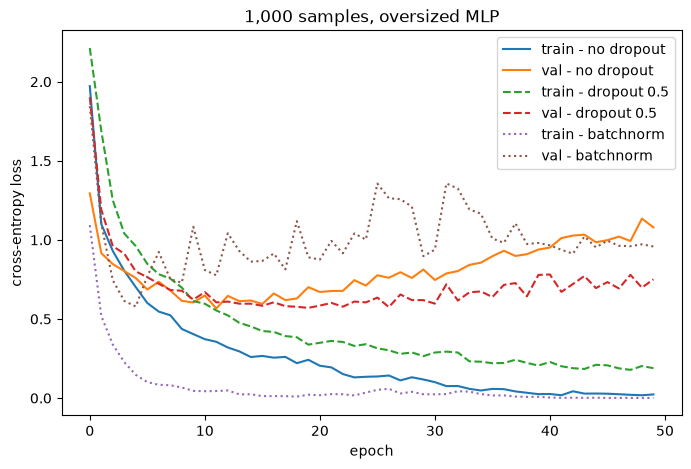

In [5]:
"""Week 5 Mon - prove overfitting, then prove dropout reduces it.

Trains a deliberately oversized MLP on only 1,000 FashionMNIST images,
once without dropout and once with, and plots all four loss curves.
"""

import os

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor

N_TRAIN = 1000
N_VAL = 1000
BATCH_SIZE = 125
EPOCHS = 50
LR = 1e-3


def get_loaders():
    """1,000 training images (deliberately too few) and 1,000 for validation."""
    train_full = datasets.FashionMNIST(
        root="data", train=True, download=True, transform=ToTensor()
    )
    val_full = datasets.FashionMNIST(
        root="data", train=False, download=True, transform=ToTensor()
    )
    train = Subset(train_full, range(N_TRAIN))
    val = Subset(val_full, range(N_VAL))
    return (
        DataLoader(train, batch_size=BATCH_SIZE, shuffle=True),
        DataLoader(val, batch_size=BATCH_SIZE),
    )


class BigMLP(nn.Module):
    """3 hidden layers x 512 units. Far too much capacity for 1,000 images."""

    def __init__(self, p_drop=0.0, use_bn = False):
        super().__init__()
        sizes = [28 * 28, 512, 512, 512]
        layers = [nn.Flatten()]
        for i in range(3):
            layers.append(nn.Linear(sizes[i], sizes[i + 1], bias = not use_bn))
            if use_bn:
                layers.append(nn.BatchNorm1d(sizes[i+1]))
            layers.append(nn.ReLU())
            if p_drop > 0:
                layers.append(nn.Dropout(p_drop))
        layers.append(nn.Linear(512, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def run(p_drop, use_bn = False, seed=0):
    """Train once. Returns (train_losses, val_losses), one entry per epoch."""
    torch.manual_seed(seed)
    train_loader, val_loader = get_loaders()

    model = BigMLP(p_drop, use_bn)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

    train_hist, val_hist = [], []

    for epoch in range(EPOCHS):
        model.train()
        running = 0.0
        for X, y in train_loader:
            pred = model(X)
            loss = loss_fn(pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running += loss.item()
        train_hist.append(running / len(train_loader))

        model.eval()
        running = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                running += loss_fn(model(X), y).item()
        val_hist.append(running / len(val_loader))

        print(
            f"p={p_drop}  epoch {epoch + 1:2d}  "
            f"train {train_hist[-1]:.4f}  val {val_hist[-1]:.4f}"
        )

    return train_hist, val_hist


if __name__ == "__main__":
    train_plain, val_plain = run(p_drop=0.0)
    train_drop, val_drop = run(p_drop=0.5)
    train_bn, val_bn = run(p_drop=0.0, use_bn=True)

    plt.figure(figsize=(8, 5))
    plt.plot(train_plain, label="train - no dropout")
    plt.plot(val_plain, label="val - no dropout")
    plt.plot(train_drop, "--", label="train - dropout 0.5")
    plt.plot(val_drop, "--", label="val - dropout 0.5")
    plt.xlabel("epoch")
    plt.ylabel("cross-entropy loss")
    plt.title("1,000 samples, oversized MLP")
    plt.plot(train_bn, ":", label="train - batchnorm")
    plt.plot(val_bn, ":", label="val - batchnorm")
    plt.legend()

    os.makedirs("notes", exist_ok=True)
    plt.savefig("notes/overfitting.png", dpi=150, bbox_inches="tight")
    plt.show()